# Hotel Booking Cancellation Prediction

## Problem Statement
Some hotel bookings get cancelled before the guest arrives. In this project, I use
booking details to predict whether a reservation will be cancelled. I compare Logistic
Regression and a Decision Tree to see how well they identify these bookings.

The target column is `is_canceled`: **0 means not cancelled and 1 means cancelled**.

## About the Dataset
The dataset has 119,390 bookings and 32 columns. It includes a city hotel and a resort
hotel in Portugal, with arrival dates from July 2015 to August 2017. The columns contain
details such as lead time, number of guests, length of stay and previous bookings.

I start by checking and cleaning the data, then explore cancellation patterns before
preparing the features and training the models.

In [1]:
# Import All the Required Libraries

# Data handling
import pandas as pd
import numpy as np

# Charts
import matplotlib.pyplot as plt
import seaborn as sns

# Saving charts and results
from pathlib import Path
import json

# Train/test split and cross-validation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

In [2]:
# Load the Dataset

df = pd.read_csv(r"C:\Users\Acer\Documents\Hotel Booking Cancellation Project\Dataset\hotel_bookings.csv")
df.shape

(119390, 32)

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# Check for Duplicate Rows

df.duplicated().sum()

np.int64(31994)

In [5]:
# Remove Exact Duplicate Rows

original_rows = len(df)
df = df.drop_duplicates().copy()
print('Rows after removing duplicates:', len(df))
print('Duplicate rows removed:', original_rows - len(df))

Rows after removing duplicates: 87396
Duplicate rows removed: 31994


There are 31,994 exact duplicate rows. I removed these before continuing with the
analysis. This leaves 87,396 rows. The original CSV is kept as downloaded.

In [6]:
# Check Missing Values and Data Types

print(df.isnull().sum())
print('\nData types:')
print(df.dtypes)

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             452
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             12193
company                           82137


In [7]:
# Numeric Feature Summary

df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87392.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,75203.000000,5259.000000,87396.000000,87396.000000,87396.000000,87396.000000
mean,0.274898,79.891368,2016.210296,26.838334,15.815541,1.005263,2.625395,1.875795,0.138640,0.010824,0.039075,0.030413,0.183990,0.271603,94.138306,183.081384,0.749565,106.337246,0.084226,0.698567
std,0.446466,86.052325,0.686102,13.674572,8.835146,1.031921,2.053584,0.626500,0.455881,0.113597,0.193775,0.369145,1.731894,0.727245,113.188172,130.557608,10.015731,55.013953,0.281533,0.831946
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,47.000000,0.000000,72.000000,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,169.000000,0.000000,98.100000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,263.000000,0.000000,134.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [8]:
# Check Bookings with No Guests or No Nights

zero_guests = ((df['adults'] + df['children'] + df['babies']) == 0)
zero_nights = ((df['stays_in_weekend_nights'] + df['stays_in_week_nights']) == 0)

print('Bookings with zero guests:', zero_guests.sum())
print('Bookings with zero nights:', zero_nights.sum())

# Limit this project to overnight bookings with at least one known guest.
# Missing children values remain missing and will be filled in the pipeline.
df = df.loc[~zero_guests & ~zero_nights].copy()
print('Rows used in this project:', len(df))

Bookings with zero guests: 166
Bookings with zero nights: 651
Rows used in this project: 86639


### Cleaning Notes
There are a few missing values in `children` and `country`. I will fill these through
the preprocessing pipeline using the training median and most common category.

For this project, I am keeping overnight bookings and removing records with zero guests
or zero nights. After this step, 86,639 bookings remain. I will also drop `agent` and
`company`, since they contain identification codes rather than numerical measurements.

In [9]:
# EDA: Target Variable Distribution

print(df['is_canceled'].value_counts())
print('\nPercentage:')
print((df['is_canceled'].value_counts(normalize=True) * 100).round(2))

is_canceled
0    62653
1    23986
Name: count, dtype: int64

Percentage:
is_canceled
0    72.32
1    27.68
Name: proportion, dtype: float64


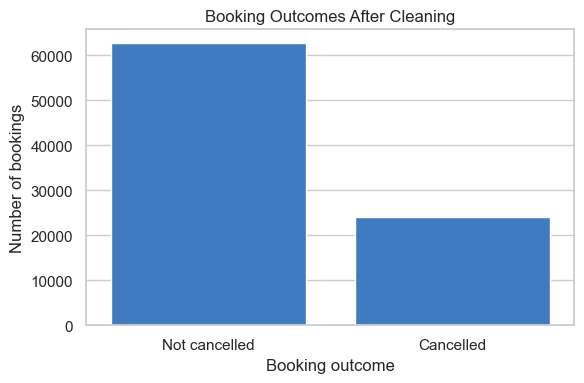

In [10]:
# Plot the Booking Outcomes

sns.set_theme(style='whitegrid')
results_folder = Path(r"C:\Users\Acer\Documents\Hotel Booking Cancellation Project\Results")
results_folder.mkdir(exist_ok=True)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_canceled', color='#2a78d6')
plt.xticks([0, 1], ['Not cancelled', 'Cancelled'])
plt.title('Booking Outcomes After Cleaning')
plt.xlabel('Booking outcome')
plt.ylabel('Number of bookings')
plt.tight_layout()
plt.savefig(results_folder / '01_booking_outcomes.png', dpi=150)
plt.show()

,Bookings,Cancellation rate
hotel,,
City Hotel,53043,0.302
Resort Hotel,33596,0.237


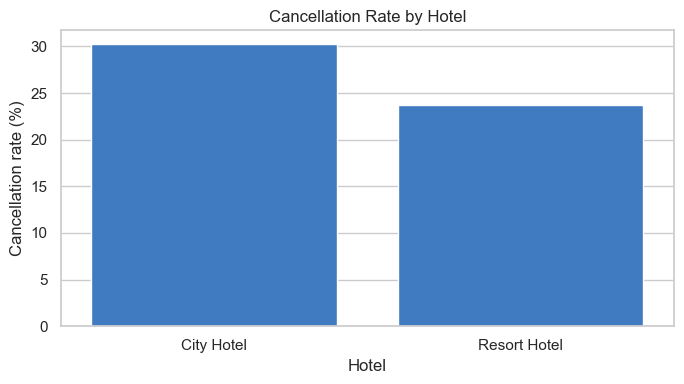

In [11]:
# Bivariate: Cancellation Rate by Hotel

hotel_summary = df.groupby('hotel')['is_canceled'].agg(['count', 'mean'])
hotel_summary.columns = ['Bookings', 'Cancellation rate']
display(hotel_summary.round(3))

hotel_risk = df.groupby('hotel')['is_canceled'].mean() * 100
plt.figure(figsize=(7, 4))
sns.barplot(x=hotel_risk.index, y=hotel_risk.values, color='#2a78d6')
plt.title('Cancellation Rate by Hotel')
plt.xlabel('Hotel')
plt.ylabel('Cancellation rate (%)')
plt.tight_layout()
plt.savefig(results_folder / '02_hotel_cancellation_rate.png', dpi=150)
plt.show()

,Bookings,Cancellation rate
market_segment,,
Undefined,2,1.000
Online TA,51285,0.355
Groups,4892,0.272
Aviation,222,0.198
Offline TA/TO,13749,0.150
Direct,11652,0.149
Corporate,4155,0.122
Complementary,682,0.122


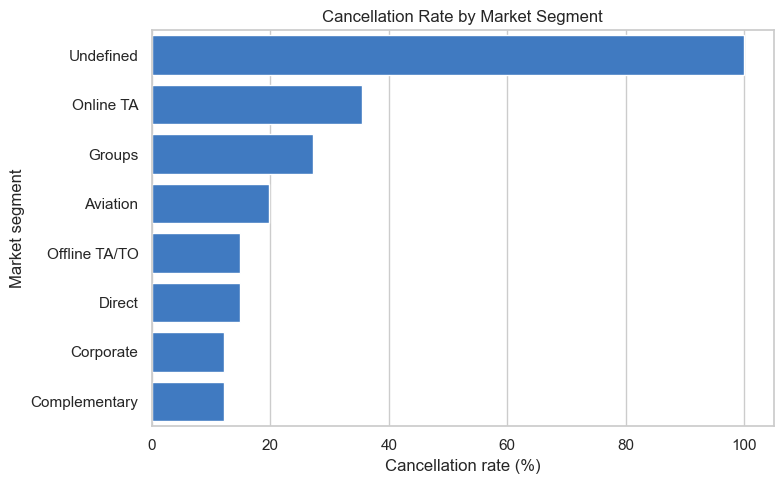

In [12]:
# Compare Market Segments

segment_summary = df.groupby('market_segment')['is_canceled'].agg(['count', 'mean'])
segment_summary.columns = ['Bookings', 'Cancellation rate']
segment_summary = segment_summary.sort_values('Cancellation rate', ascending=False)
display(segment_summary.round(3))

plt.figure(figsize=(8, 5))
sns.barplot(x=segment_summary['Cancellation rate'] * 100,
            y=segment_summary.index, color='#2a78d6')
plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Cancellation rate (%)')
plt.ylabel('Market segment')
plt.tight_layout()
plt.savefig(results_folder / '03_market_segment.png', dpi=150)
plt.show()

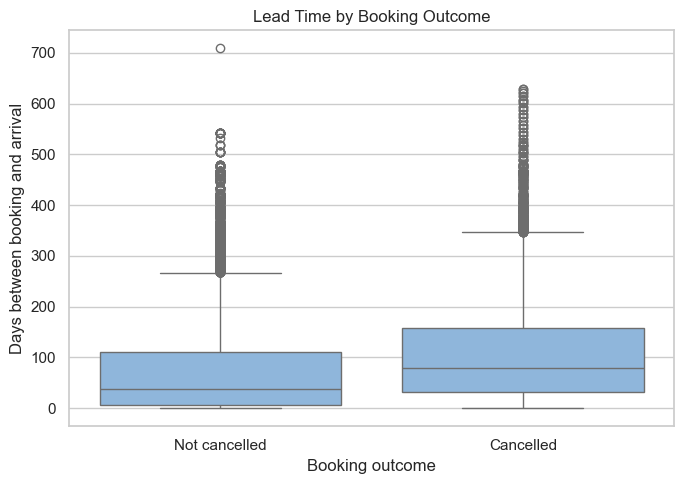

,lead_time,adults,previous_cancellations
is_canceled,,,
0,70.52,1.85,0.02
1,105.82,1.96,0.06


In [13]:
# Lead Time by Cancellation Status

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='is_canceled', y='lead_time', color='#82b7e8')
plt.xticks([0, 1], ['Not cancelled', 'Cancelled'])
plt.title('Lead Time by Booking Outcome')
plt.xlabel('Booking outcome')
plt.ylabel('Days between booking and arrival')
plt.tight_layout()
plt.savefig(results_folder / '04_lead_time.png', dpi=150)
plt.show()

df.groupby('is_canceled')[['lead_time', 'adults', 'previous_cancellations']].mean().round(2)

The City Hotel has a higher cancellation rate than the Resort Hotel in the cleaned
data. Cancelled bookings also tend to have longer lead times.

The Undefined market segment shows a 100% cancellation rate, but it contains only two
bookings. I would not draw a general conclusion from such a small group.

In [14]:
# Feature Engineering

df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['previous_bookings'] = df['previous_cancellations'] + df['previous_bookings_not_canceled']

# Guests with no previous bookings receive a history rate of 0.
df['previous_cancellation_rate'] = (
    df['previous_cancellations'] / df['previous_bookings'].replace(0, np.nan)
).fillna(0)

df[['total_nights', 'total_guests', 'previous_bookings', 'previous_cancellation_rate']].describe()

,total_nights,total_guests,previous_bookings,previous_cancellation_rate
count,86639.000000,86635.000000,86639.000000,86639.000000
mean,3.653285,2.030657,0.214972,0.013813
std,2.735811,0.790718,1.912968,0.112178
min,1.000000,1.000000,0.000000,0.000000
25%,2.000000,2.000000,0.000000,0.000000
50%,3.000000,2.000000,0.000000,0.000000
75%,5.000000,2.000000,0.000000,0.000000
max,69.000000,55.000000,78.000000,1.000000


## Selecting the Features
I am removing `reservation_status` and `reservation_status_date` because they reveal
what happened to the booking. Including them would give the model the answer.

I am also leaving out the assigned room, booking changes and waiting-list duration,
since these can change after a booking is made. For the same reason, I am excluding
the recorded daily rate, deposit information, parking requirements and special requests:
the dataset does not clearly show when these values became available.

The remaining inputs include the reserved room, guest details, lead time and previous
booking history, along with the features created above.

In [15]:
# Train/Test Split with Stratification

drop_cols = ['reservation_status', 'reservation_status_date', 'assigned_room_type',
             'booking_changes', 'days_in_waiting_list', 'agent', 'company', 'adr',
             'deposit_type', 'required_car_parking_spaces', 'total_of_special_requests',
             'arrival_date_week_number']

X = df.drop(columns=drop_cols + ['is_canceled'])
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Training shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Training cancellation rate:', round(y_train.mean(), 3))
print('Test cancellation rate:', round(y_test.mean(), 3))

Training shape: (69311, 23)
Test shape: (17328, 23)
Training cancellation rate: 0.277
Test cancellation rate: 0.277


In [16]:
# Preprocessing Pipeline: Imputation, Scaling and One-Hot Encoding

numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Numeric features: ['lead_time', 'arrival_date_year', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'total_nights', 'total_guests', 'previous_bookings', 'previous_cancellation_rate']
Categorical features: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'customer_type']


The pipeline keeps the preprocessing steps together. It fills missing values, scales
the numerical columns and converts categories into numbers using one-hot encoding.
These steps are fitted on training data only, including within each cross-validation fold.
`handle_unknown='ignore'` handles categories that appear later but were absent during training.

In [17]:
# Train the Baseline Logistic Regression Model

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, random_state=42))
])

baseline_scores = cross_val_score(baseline_model, X_train, y_train,
                                 cv=cv, scoring='roc_auc')
baseline_model.fit(X_train, y_train)
print('Baseline CV ROC-AUC:', baseline_scores.mean())

Baseline CV ROC-AUC: 0.7852143743968666


In [18]:
# Tune Logistic Regression: Class Weights and Regularization

tuned_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
])

param_grid = {'classifier__C': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(tuned_model, param_grid, cv=cv, scoring='roc_auc')
grid_search.fit(X_train, y_train)

print('Best C:', grid_search.best_params_)
print('Best CV ROC-AUC:', grid_search.best_score_)

Best C: {'classifier__C': 1}
Best CV ROC-AUC: 0.7851880419644859


In [19]:
# Alternate Model: Decision Tree

dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42))
])

dt_scores = cross_val_score(dt_model, X_train, y_train, cv=cv, scoring='roc_auc')
dt_model.fit(X_train, y_train)
print('Decision Tree CV ROC-AUC:', dt_scores.mean())

Decision Tree CV ROC-AUC: 0.7826095585425585


In [20]:
# Compare Models Using Training Cross-Validation

comparison = pd.DataFrame({
    'Model': ['Baseline Logistic Regression', 'Tuned Logistic Regression', 'Decision Tree'],
    'CV ROC-AUC': [baseline_scores.mean(), grid_search.best_score_, dt_scores.mean()]
}).sort_values('CV ROC-AUC', ascending=False)

comparison.to_csv(results_folder / 'model_comparison.csv', index=False)
display(comparison.round(4))

model_list = {
    'Baseline Logistic Regression': baseline_model,
    'Tuned Logistic Regression': grid_search.best_estimator_,
    'Decision Tree': dt_model
}
best_model_name = comparison.iloc[0]['Model']
best_model = model_list[best_model_name]
best_model.fit(X_train, y_train)
print('Selected model:', best_model_name)

,Model,CV ROC-AUC
0,Baseline Logistic Regression,0.7852
1,Tuned Logistic Regression,0.7852
2,Decision Tree,0.7826


Selected model: Baseline Logistic Regression


## Evaluating the Selected Model
I use the mean cross-validation ROC-AUC to select the model, then check its performance
on the test set. The prediction threshold stays at 0.50.

Precision tells me how many predicted cancellations were correct. Recall tells me how
many actual cancellations the model found. F1 combines precision and recall. ROC-AUC
and Average Precision help assess the model's scores across different thresholds.

In [21]:
# Evaluate the Selected Model on the Test Set

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Not cancelled', 'Cancelled']))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))
print('Average Precision:', average_precision_score(y_test, y_proba))

test_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'Average Precision'],
    'Score': [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred),
              recall_score(y_test, y_pred), f1_score(y_test, y_pred),
              roc_auc_score(y_test, y_proba), average_precision_score(y_test, y_proba)]
})
test_results.to_csv(results_folder / 'test_metrics.csv', index=False)
test_results.round(4)

               precision    recall  f1-score   support

Not cancelled       0.78      0.92      0.85     12531
    Cancelled       0.62      0.34      0.44      4797

     accuracy                           0.76     17328
    macro avg       0.70      0.63      0.64     17328
 weighted avg       0.74      0.76      0.73     17328

Confusion Matrix:
[[11543   988]
 [ 3183  1614]]
ROC-AUC: 0.7789165254991468
Average Precision: 0.584584838268377


,Metric,Score
0,Accuracy,0.7593
1,Precision,0.6203
2,Recall,0.3365
3,F1,0.4363
4,ROC-AUC,0.7789
5,Average Precision,0.5846


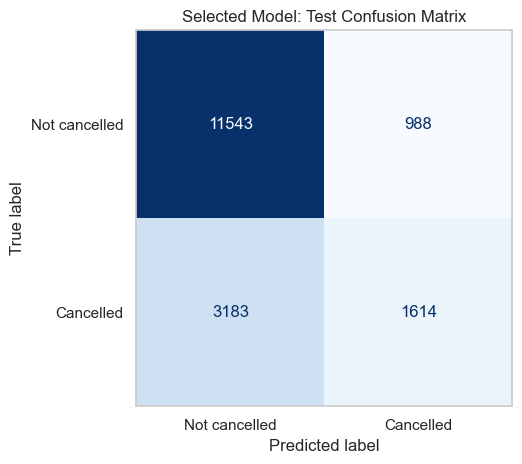

In [22]:
# Plot the Confusion Matrix

ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
    display_labels=['Not cancelled', 'Cancelled'], cmap='Blues', colorbar=False)
plt.grid(False)
plt.title('Selected Model: Test Confusion Matrix')
plt.tight_layout()
plt.savefig(results_folder / '05_confusion_matrix.png', dpi=150)
plt.show()

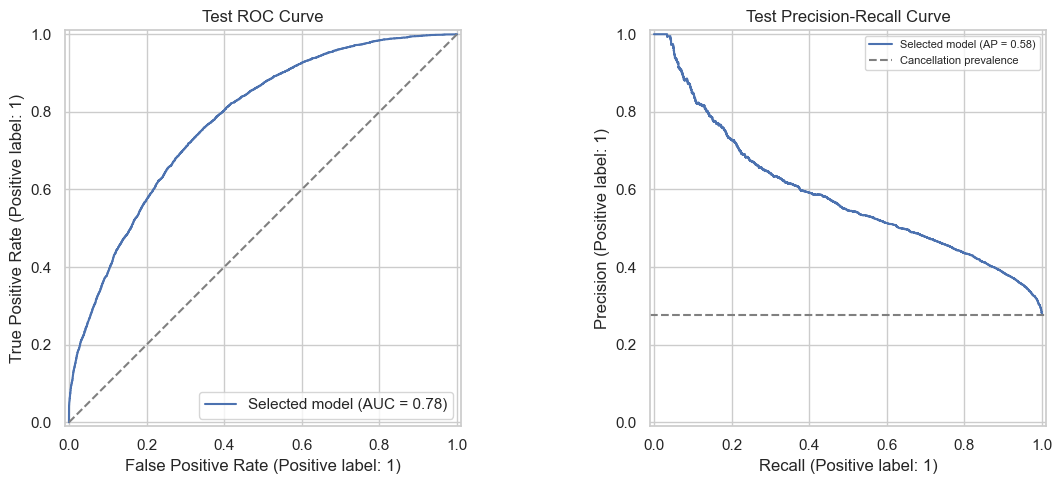

In [23]:
# ROC Curve and Precision-Recall Curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], name='Selected model')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[0].set_title('Test ROC Curve')
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1], name='Selected model')
axes[1].axhline(y_test.mean(), linestyle='--', color='grey', label='Cancellation prevalence')
axes[1].set_title('Test Precision-Recall Curve')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(results_folder / '06_evaluation_curves.png', dpi=150)
plt.show()

In [24]:
# Interpret the Tuned Logistic Regression Coefficients

lr_best = grid_search.best_estimator_
feature_names = lr_best.named_steps['preprocessor'].get_feature_names_out()
coefficients = lr_best.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)
coef_df.to_csv(results_folder / 'logistic_regression_coefficients.csv', index=False)
coef_df.head(15)

,feature,coefficient,abs_coefficient
99,cat__country_HKG,2.271659,2.271659
38,cat__country_ARE,2.177601,2.177601
151,cat__country_NZL,-1.966689,1.966689
51,cat__country_BGR,-1.752263,1.752263
94,cat__country_GIB,1.684355,1.684355
173,cat__country_SRB,-1.667515,1.667515
91,cat__country_GEO,1.482829,1.482829
134,cat__country_MDV,1.479663,1.479663
147,cat__country_NGA,1.374025,1.374025
35,cat__country_AGO,1.339097,1.339097


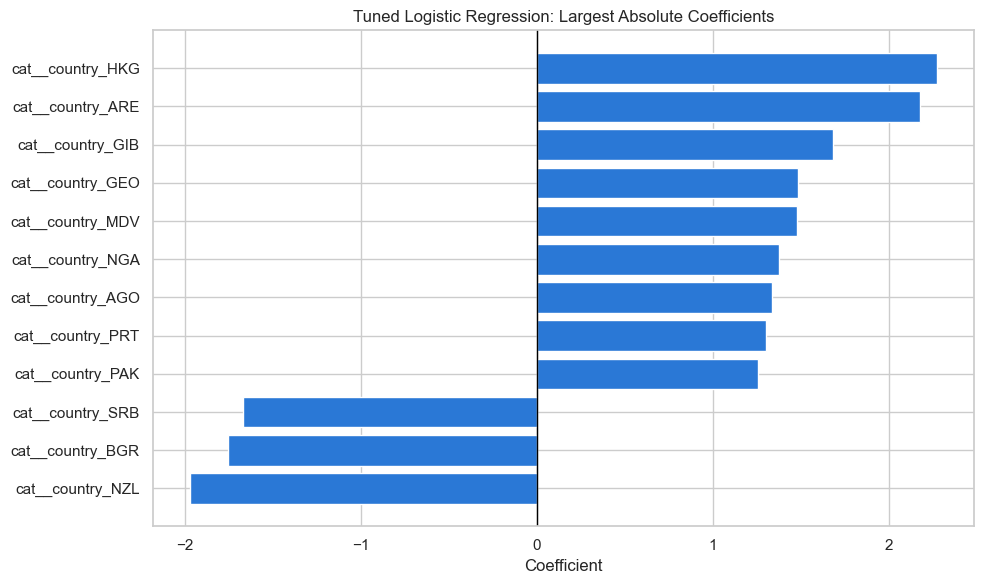

In [25]:
# Plot the Top Logistic Regression Coefficients

top_features = coef_df.head(12).sort_values('coefficient')
plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['coefficient'], color='#2a78d6')
plt.axvline(0, color='black', linewidth=1)
plt.title('Tuned Logistic Regression: Largest Absolute Coefficients')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.savefig(results_folder / '07_logistic_coefficients.png', dpi=150)
plt.show()

This table and chart describe the tuned Logistic Regression model. Positive coefficients
raise its cancellation score, while negative coefficients lower it when the other inputs
are held fixed. The final model selection is shown in the comparison table above.

In [26]:
# Save the Main Results

summary = {
    'original_rows': original_rows,
    'cleaned_rows': len(df),
    'training_rows': len(X_train),
    'test_rows': len(X_test),
    'cleaned_cancellation_rate': float(y.mean()),
    'selected_model': best_model_name,
    'best_logistic_C': float(grid_search.best_params_['classifier__C']),
    'test_metrics': dict(zip(test_results['Metric'], test_results['Score'])),
    'confusion_matrix': confusion_matrix(y_test, y_pred).tolist()
}
with open(results_folder / 'project_summary.json', 'w') as file:
    json.dump(summary, file, indent=2)

hotel_summary.to_csv(results_folder / 'hotel_summary.csv')
segment_summary.to_csv(results_folder / 'market_segment_summary.csv')
print('Selected model:', best_model_name)
print('Test recall:', round(recall_score(y_test, y_pred), 3))
print('Test precision:', round(precision_score(y_test, y_pred), 3))
print('Results saved in:', results_folder)

Selected model: Baseline Logistic Regression
Test recall: 0.336
Test precision: 0.62
Results saved in: C:\Users\Acer\Documents\Hotel Booking Cancellation Project\Results


## Conclusion
After cleaning, 27.68% of the bookings were cancelled. The City Hotel had a cancellation
rate of 30.21%, compared with 23.71% for the Resort Hotel. Cancelled bookings had a mean
lead time of about 106 days, compared with 71 days for bookings that were not cancelled.

Baseline Logistic Regression had the highest cross-validation ROC-AUC, although its
score was almost the same as the tuned version. Tuning did not give a clear improvement.

On the test set, the selected model achieved **75.93% accuracy**, **62.03% precision**
and **33.65% recall**. Its ROC-AUC was **0.779** and F1 was **0.436**.

It correctly identified 1,614 cancellations, missed 3,183 and incorrectly flagged 988
bookings that were not cancelled. The accuracy looks reasonable, but the low recall
shows that the model still misses many cancellations.